In [10]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('/home/ece346-15/Documents/SAFE_ROS2/src')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
import rclpy
from rclpy.node import Node
import lanelet2
from Routing.Routing.routing.routing import Routing
from lanelet2.core import (AllWayStop, AttributeMap, BasicPoint2d,
                            BoundingBox2d, Lanelet, LaneletMap,
                            LaneletWithStopLine, LineString2d, LineString3d, Point2d, Point3d,
                            BasicPoint2d, BasicPoint3d,
                            RightOfWay, TrafficLight, getId)
from lanelet2.projection import (UtmProjector, MercatorProjector,
                                    LocalCartesianProjector, GeocentricProjector)
from lanelet2.matching import Pose2d, Object2d, ObjectWithCovariance2d, PositionCovariance2d

from Routing.Routing.routing.lanelet_wrapper import LaneletWrapper

import numpy as np
from Routing.Routing.routing.utils import *
from Routing.Routing.routing.build_lanelet_map.ui import UI
import matplotlib.pyplot as plt

[INFO] [1761167206.045058945] [routing_node]: Loading map from /home/ece346-15/Documents/SAFE_ROS2/src/Routing/maps/track.osm with lane_change_cost=1.0


Loading image from ../maps/track1.jpeg


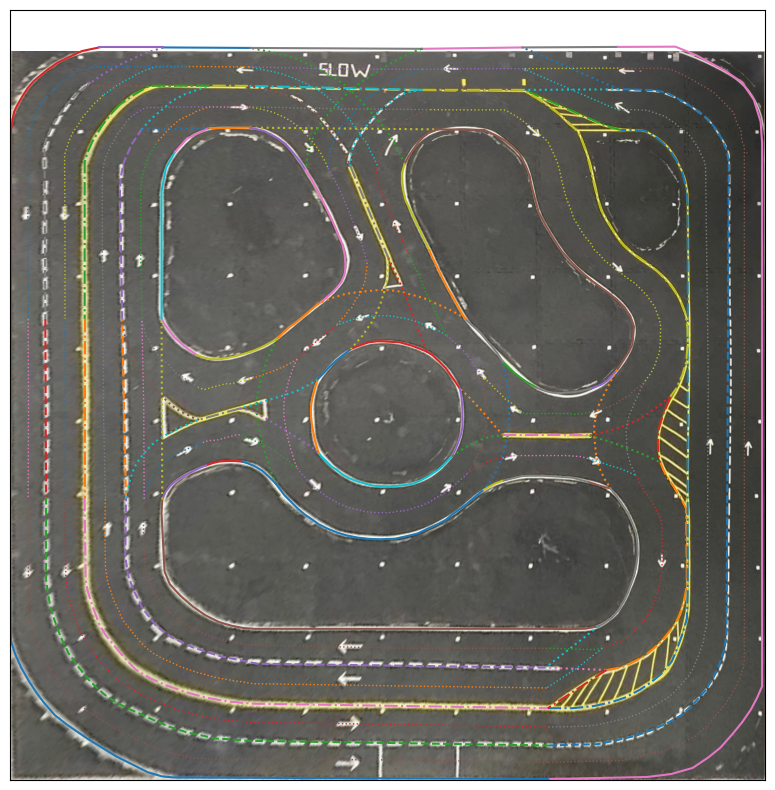

In [12]:
rclpy.init(args=None)

test_node = Routing()


ui = UI("../maps/track1.jpeg", 6.05, 6.05)
#wrapper = LaneletWrapper("../maps/track.osm", test_node)
linestring_layer = test_node.lanelet_wrapper.lanelet_map.lineStringLayer
for linestring in linestring_layer:
    ui.plot_linestring(linestring, update=False)

# loop through lanelets
lanelet_layer = test_node.lanelet_wrapper.lanelet_map.laneletLayer
for lanelet in lanelet_layer:
    # ui.plot_lanelet(lanelet, update=False)
    ui.plot_linestring(lanelet.centerline, update=False)
ui.update_plot()

# create debug lanelet map
map_deub = test_node.lanelet_wrapper.routing_graph.getDebugLaneletMap()
# wrapper.save_lanelet_map(map_deub, "../../cfg/track_route.osm")


In [15]:
for l in test_node.lanelet_wrapper.lanelet_layer:
    print(l.id)
# Get a lanelet by id
lanelet = test_node.lanelet_wrapper.lanelet_layer[1032]

# Get the length of the lanelet
L = test_node.lanelet_wrapper.get_lanelet_length(lanelet)
centerline = lanelet.centerline
left_bound = lanelet.leftBound
for pt in centerline:
    print('c ', pt.x, pt.y)
    
for pt in left_bound:
    print('l ', pt.x, pt.y)
    
# Project a point to the centerline
print(test_node.lanelet_wrapper.project_xy_to_linestring(0.2, 3, centerline))

1932
1855
1737
1657
1631
1583
1953
1540
1876
1522
1515
1493
1687
1451
1181
1173
1163
1158
1419
1802
1153
1917
1032
1293
1143
1971
1027
1616
1557
1203
1787
1138
1818
1228
1474
1238
1680
1267
1707
1412
1148
1266
1272
1273
1892
1833
1184
1302
1292
1601
1306
1073
1309
1312
1371
1429
c  0.144529434481631 3.8277530233448793
c  0.1476525027958363 3.089941744954076
c  0.144529434481631 2.348894510381355
l  0.28195111947611146 3.8277530233448815
l  0.28819725610452207 2.3521304665632754
(0.14727438891333391, 3.000222206733457)


l1:  [id: 1267, left id: 1185 (inverted), right id: 1252]
l2:  [id: 1203, left id: 1185, right id: 1051]


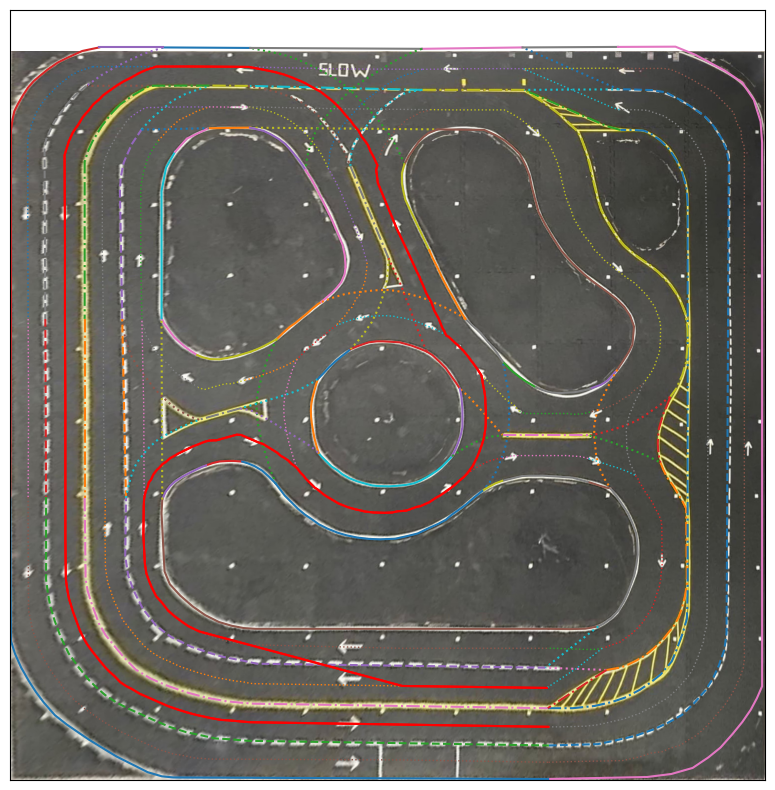

In [19]:
l1 = test_node.lanelet_wrapper.lanelet_layer[1267]
l2 = test_node.lanelet_wrapper.lanelet_layer[1203]
print("l1: ", l1)
print("l2: ", l2)

path = test_node.lanelet_wrapper.routing_graph.shortestPath(l1, l2)

c = test_node.lanelet_wrapper.get_path_centerline(path)
c=  np.array(c)

c_index = ui.xy2point(c.T).T
ui.ax.plot(c_index[:,0], c_index[:,1], '-r')
ui.fig

(220, 5)


[WARN] [1761167982.581688031] [routing_node]: End point [5, 2] is not inside a lanelet


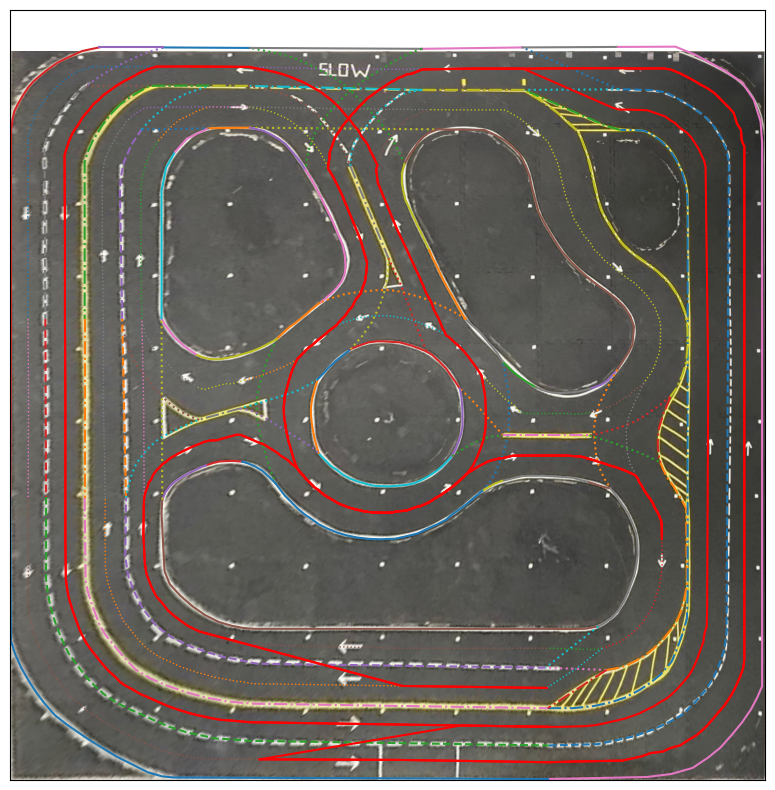

In [22]:
c = test_node.lanelet_wrapper.get_shortest_path(2, 0.1, 5, 2, False)

c=  np.array(c)
print(c.shape)

c_index = ui.xy2point(c.T).T
ui.ax.plot(c_index[:,0], c_index[:,1], '-r')
ui.fig

In [23]:
rclpy.shutdown()